In [1]:
! pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 86.0 MB/s eta 0:00:00


In [2]:
import requests
import os
import json
import pandas as pd
import gzip, json
from collections import defaultdict, Counter
from torch_geometric.data import Data

In [3]:
urls = {"meta":"https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Toys_and_Games.json.gz","reviews":"https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Toys_and_Games.json.gz"}
for name, url in urls.items():
  file_name = f"{name}_Toys_and_Games.json.gz"
  if not os.path.exists(file_name):
    print(f"Downloading {file_name}...")
    response = requests.get(url)
    with open(file_name, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"Done!")
  else:
    print(f"Already exists: {file_name}")


Done!
Done!


In [4]:
def parse_gz(path):
    with gzip.open(path, "rb") as f:
        for line in f:
            try:
                yield json.loads(line)
            except:
                try:
                    yield eval(line)
                except:
                    pass

# Count labels at each depth level
by_depth = defaultdict(Counter)

for item in parse_gz("meta_Toys_and_Games.json.gz"):
    for path in item.get("categories", []):
        for depth, label in enumerate(path):
            by_depth[depth][label] += 1

for depth in sorted(by_depth.keys()):
    print(f"\n Level {depth} ({len(by_depth[depth])} unique labels) ")
    for label, count in by_depth[depth].most_common(20):
        print(f"  {count:>6}  {label}")


 Level 0 (22 unique labels) 
  336460  Toys & Games
     753  Clothing, Shoes & Jewelry
     491  Sports & Outdoors
     248  Video Games
     119  Health & Personal Care
      69  Cell Phones & Accessories
      55  Software
      23  Baby Products
      22  Electronics
      14  Home & Kitchen
      12  Books
      12  Kindle Store
       9  Tools & Home Improvement
       7  Musical Instruments
       7  Beauty
       5  Arts, Crafts & Sewing
       3  Automotive
       2  Movies & TV
       2  Industrial & Scientific
       1  Patio, Lawn & Garden

 Level 1 (118 unique labels) 
   48885  Action Figures & Statues
   38838  Games
   34812  Stuffed Animals & Plush
   26325  Hobbies
   22167  Dolls & Accessories
   19680  Toy Remote Control & Play Vehicles
   17649  Party Supplies
   14666  Arts & Crafts
   14545  Sports & Outdoor Play
   13659  Puzzles
   12569  Learning & Education
   11725  Novelty & Gag Toys
   10116  Building Toys
    9317  Grown-Up Toys
    9105  Dress Up & Pret

In [5]:
records = []

for item in parse_gz("meta_Toys_and_Games.json.gz"):
    records.append(item)

df = pd.DataFrame(records)
print(df.shape)
print(df.columns.tolist())

(336072, 9)
['asin', 'description', 'title', 'price', 'salesRank', 'imUrl', 'brand', 'categories', 'related']


In [6]:
df.head()

,asin,description,title,price,salesRank,imUrl,brand,categories,related
0,0000191639,"Three Dr. Suess' Puzzles: Green Eggs and Ham, ...",Dr. Suess 19163 Dr. Seuss Puzzle 3 Pack Bundle,37.12,{'Toys & Games': 612379},http://ecx.images-amazon.com/images/I/414PLROX...,Dr. Seuss,"[[Toys & Games, Puzzles, Jigsaw Puzzles]]",NaN
1,0005069491,NaN,Nursery Rhymes Felt Book,NaN,{'Toys & Games': 576683},http://ecx.images-amazon.com/images/I/51z4JDBC...,NaN,[[Toys & Games]],NaN
2,0076561046,Learn Fractions Decimals Percents using flash ...,Fraction Decimal Percent Card Deck,NaN,{'Toys & Games': 564211},http://ecx.images-amazon.com/images/I/51ObabPu...,NaN,"[[Toys & Games, Learning & Education, Flash Ca...",{'also_viewed': ['0075728680']}
3,0131358936,"New, Sealed. Fast Shipping with tracking, buy ...",NaN,36.22,{'Software': 8080},http://ecx.images-amazon.com/images/I/51%2B7Ej...,NaN,"[[Toys & Games, Learning & Education, Mathemat...","{'also_bought': ['0321845536', '0078787572'], ..."
4,0133642984,NaN,Algebra 2 California Teacher Center,731.93,{'Toys & Games': 1150291},http://ecx.images-amazon.com/images/I/51VK%2BL...,Prentice Hall,"[[Toys & Games, Learning & Education, Mathemat...",NaN


In [7]:
df.dtypes

,0
asin,object
description,object
title,object
price,float64
salesRank,object
imUrl,object
brand,object
categories,object
related,object


In [8]:
df.isnull().sum()

,0
asin,0
description,33285
title,898
price,93381
salesRank,8849
imUrl,350
brand,150706
categories,0
related,71687


In [9]:
df['description'].notna().sum()

np.int64(302787)

In [10]:
both_missing = df['title'].isna() & df['description'].isna()
print(both_missing.sum())

406


In [11]:
import torch
from torch_geometric.data import Data

# map every asin to an integer index
asin2idx = {asin: i for i, asin in enumerate(df['asin'])}

# build edge list
src_list = []
dst_list = []

edge_types = ['also_bought']

for _, row in df.iterrows():
    related = row['related']
    if not isinstance(related, dict):
        continue
    for etype in edge_types:
        for neighbor_asin in related.get(etype, []):
            if neighbor_asin in asin2idx:
                src_list.append(asin2idx[row['asin']])
                dst_list.append(asin2idx[neighbor_asin])

# add both directions
src_all = src_list + dst_list
dst_all = dst_list + src_list

#  remove duplicates
edges = set()
src_clean = []
dst_clean = []

for s, d in zip(src_all, dst_all):
    if s == d:
        continue
    if (s, d) in edges:
        continue
    edges.add((s, d))
    src_clean.append(s)
    dst_clean.append(d)


edge_index = torch.tensor([src_clean, dst_clean], dtype=torch.long)

print(f"Nodes:          {len(asin2idx)}")
print(f"Edges:          {edge_index.shape[1]}")

degree = Counter()
for src in edge_index[0].tolist():
    degree[src] += 1
print(f"Isolated nodes: {len(asin2idx) - len(degree)}")
print(f"Connected nodes: {len(degree)}")

Nodes:          336072
Edges:          7791014
Isolated nodes: 155213
Connected nodes: 180859


In [12]:
def get_label(categories):
    if not categories:
        return None
    for path in categories:
        if path and path[0] == 'Toys & Games' and len(path) >= 2:
            return path[1]
    return None

df['label'] = df['categories'].apply(get_label)

df = df[df['label'].notna()].reset_index(drop=True)

print(f"Products after dropping level-0 only: {len(df)}")
print(f"Unique labels: {df['label'].nunique()}")
print()
print(df['label'].value_counts())

Products after dropping level-0 only: 317329
Unique labels: 18

label
Action Figures & Statues              48875
Games                                 38817
Stuffed Animals & Plush               34805
Hobbies                               26322
Dolls & Accessories                   22150
Toy Remote Control & Play Vehicles    19678
Party Supplies                        17566
Arts & Crafts                         14666
Sports & Outdoor Play                 14542
Puzzles                               13655
Learning & Education                  12541
Novelty & Gag Toys                    11720
Building Toys                         10116
Grown-Up Toys                          9256
Dress Up & Pretend Play                9066
Electronics for Kids                   6277
Baby & Toddler Toys                    5145
Tricycles, Scooters & Wagons           2132
Name: count, dtype: int64


In [13]:
label_counts = df['label'].value_counts()

print(f"Classes with >= 100 products: {(label_counts >= 100).sum()}")
print(f"Classes with >= 50 products:  {(label_counts >= 50).sum()}")
print(f"Classes with >= 10 products:  {(label_counts >= 10).sum()}")
print(f"Classes with < 10 products:   {(label_counts < 10).sum()}")
print(f"Classes with 1 product:       {(label_counts == 1).sum()}")
print()
print(f"Products in classes >= 100:   {label_counts[label_counts >= 100].sum()}")
print(f"Products in classes < 10:     {label_counts[label_counts < 10].sum()}")

Classes with >= 100 products: 18
Classes with >= 50 products:  18
Classes with >= 10 products:  18
Classes with < 10 products:   0
Classes with 1 product:       0

Products in classes >= 100:   317329
Products in classes < 10:     0


In [14]:
# encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_idx'] = le.fit_transform(df['label'])

print(f"Classes: {df['label_idx'].nunique()}")
print(df[['label', 'label_idx']].drop_duplicates().sort_values('label_idx'))

Classes: 18
                                   label  label_idx
75              Action Figures & Statues          0
6                          Arts & Crafts          1
744                  Baby & Toddler Toys          2
95                         Building Toys          3
4                    Dolls & Accessories          4
18               Dress Up & Pretend Play          5
24                  Electronics for Kids          6
7                                  Games          7
310                        Grown-Up Toys          8
430                              Hobbies          9
1                   Learning & Education         10
17                    Novelty & Gag Toys         11
12                        Party Supplies         12
0                                Puzzles         13
315                Sports & Outdoor Play         14
10               Stuffed Animals & Plush         15
47    Toy Remote Control & Play Vehicles         16
2170        Tricycles, Scooters & Wagons         17


In [15]:
# rebuild asin2idx on df (no filtering needed, all 317k products kept)
asin2idx = {asin: i for i, asin in enumerate(df['asin'])}

src_list, dst_list = [], []
edge_types = ['also_bought']

for _, row in df.iterrows():
    related = row['related']
    if not isinstance(related, dict):
        continue
    for etype in edge_types:
        for neighbor_asin in related.get(etype, []):
            if neighbor_asin in asin2idx:
                src_list.append(asin2idx[row['asin']])
                dst_list.append(asin2idx[neighbor_asin])

src_all = src_list + dst_list
dst_all = dst_list + src_list

edges = set()
src_clean, dst_clean = [], []
for s, d in zip(src_all, dst_all):
    if s == d: continue
    if (s, d) in edges: continue
    edges.add((s, d))
    src_clean.append(s)
    dst_clean.append(d)

edge_index = torch.tensor([src_clean, dst_clean], dtype=torch.long)
print(f"Nodes: {len(asin2idx)}")
print(f"Edges: {edge_index.shape[1]}")

# check isolation
degree = Counter()
for src in edge_index[0].tolist():
    degree[src] += 1
print(f"Isolated nodes: {len(asin2idx) - len(degree)}")
print(f"Connected nodes: {len(degree)}")

Nodes: 317329
Edges: 7492956
Isolated nodes: 142207
Connected nodes: 175122


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import numpy as np

# combine title and description
df['text'] = df['title'].fillna('') + ' ' + df['description'].fillna('')
df['text'] = df['text'].str.strip()

# TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_tfidf = vectorizer.fit_transform(df['text'])

# reduce to 128 dims with SVD (same as PCA but works on sparse matrices)
svd = TruncatedSVD(n_components=128, random_state=42)
X_bow = svd.fit_transform(X_tfidf)

print(f"Feature matrix shape: {X_bow.shape}")
print(f"Explained variance:   {svd.explained_variance_ratio_.sum():.2%}")

Feature matrix shape: (317329, 128)
Explained variance:   18.34%


In [17]:
x = torch.tensor(X_bow, dtype=torch.float)
y = torch.tensor(df['label_idx'].values, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)
print(data)

Data(x=[317329, 128], edge_index=[2, 7492956], y=[317329])


In [18]:
from sklearn.model_selection import train_test_split

idx = torch.arange(len(df))

# first split off test set
idx_train_val, idx_test = train_test_split(
    idx, test_size=0.15, random_state=42,
    stratify=df['label_idx']
)

# then split train and val
idx_train, idx_val = train_test_split(
    idx_train_val, test_size=0.15/0.85, random_state=42,
    stratify=df.loc[idx_train_val.numpy(), 'label_idx']
)

data.train_mask = torch.zeros(len(df), dtype=torch.bool)
data.val_mask   = torch.zeros(len(df), dtype=torch.bool)
data.test_mask  = torch.zeros(len(df), dtype=torch.bool)

data.train_mask[idx_train] = True
data.val_mask[idx_val]     = True
data.test_mask[idx_test]   = True

print(f"Train: {data.train_mask.sum()} ({data.train_mask.sum()/len(df):.0%})")
print(f"Val:   {data.val_mask.sum()} ({data.val_mask.sum()/len(df):.0%})")
print(f"Test:  {data.test_mask.sum()} ({data.test_mask.sum()/len(df):.0%})")

Train: 222129 (70%)
Val:   47600 (15%)
Test:  47600 (15%)


In [19]:
print(data)

Data(x=[317329, 128], edge_index=[2, 7492956], y=[317329], train_mask=[317329], val_mask=[317329], test_mask=[317329])


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x):
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        return x

model = MLP(
    in_channels=128,      # BoW feature size
    hidden_channels=256,  # hidden layer size
    out_channels=142      # number of classes
)
print(model)

MLP(
  (lin1): Linear(in_features=128, out_features=256, bias=True)
  (lin2): Linear(in_features=256, out_features=142, bias=True)
)


In [21]:
from torch.optim import Adam

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

data = data.to(device)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate():
    model.eval()
    out = model(data.x)
    pred = out.argmax(dim=1)

    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean()
    val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean()
    test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean()

    return train_acc.item(), val_acc.item(), test_acc.item()

# training loop
best_val_acc = 0
best_test_acc = 0

for epoch in range(1, 201):
    loss = train()
    train_acc, val_acc, test_acc = evaluate()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc

    if epoch % 20 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | "
              f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

print(f"\nBest Val Acc:  {best_val_acc:.4f}")
print(f"Best Test Acc: {best_test_acc:.4f}")

Using device: cuda
Epoch  20 | Loss: 2.2572 | Train: 0.3874 | Val: 0.3850 | Test: 0.3869
Epoch  40 | Loss: 1.3544 | Train: 0.6690 | Val: 0.6693 | Test: 0.6680
Epoch  60 | Loss: 1.2227 | Train: 0.6867 | Val: 0.6859 | Test: 0.6836
Epoch  80 | Loss: 1.1905 | Train: 0.6929 | Val: 0.6912 | Test: 0.6895
Epoch 100 | Loss: 1.1725 | Train: 0.6958 | Val: 0.6947 | Test: 0.6931
Epoch 120 | Loss: 1.1607 | Train: 0.6975 | Val: 0.6967 | Test: 0.6943
Epoch 140 | Loss: 1.1514 | Train: 0.6987 | Val: 0.6983 | Test: 0.6962
Epoch 160 | Loss: 1.1458 | Train: 0.6998 | Val: 0.6987 | Test: 0.6972
Epoch 180 | Loss: 1.1413 | Train: 0.7006 | Val: 0.6997 | Test: 0.6980
Epoch 200 | Loss: 1.1373 | Train: 0.7010 | Val: 0.7002 | Test: 0.6985

Best Val Acc:  0.7002
Best Test Acc: 0.6986


In [22]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model_sage = GraphSAGE(128, 256, 142).to(device)
optimizer_sage = Adam(model_sage.parameters(), lr=0.01, weight_decay=5e-4)

def train_sage():
    model_sage.train()
    optimizer_sage.zero_grad()
    out = model_sage(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_sage.step()
    return loss.item()

@torch.no_grad()
def evaluate_sage():
    model_sage.eval()
    out = model_sage(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean()
    val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean()
    test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean()
    return train_acc.item(), val_acc.item(), test_acc.item()

best_val_acc = 0
best_test_acc = 0

for epoch in range(1, 201):
    loss = train_sage()
    train_acc, val_acc, test_acc = evaluate_sage()
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc
    if epoch % 20 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | "
              f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

print(f"\nBest Val Acc:  {best_val_acc:.4f}")
print(f"Best Test Acc: {best_test_acc:.4f}")

Epoch  20 | Loss: 1.7157 | Train: 0.6176 | Val: 0.6159 | Test: 0.6156
Epoch  40 | Loss: 1.1582 | Train: 0.7145 | Val: 0.7115 | Test: 0.7132
Epoch  60 | Loss: 1.0826 | Train: 0.7229 | Val: 0.7198 | Test: 0.7220
Epoch  80 | Loss: 1.0597 | Train: 0.7270 | Val: 0.7247 | Test: 0.7254
Epoch 100 | Loss: 1.0475 | Train: 0.7284 | Val: 0.7267 | Test: 0.7270
Epoch 120 | Loss: 1.0373 | Train: 0.7290 | Val: 0.7275 | Test: 0.7277
Epoch 140 | Loss: 1.0314 | Train: 0.7296 | Val: 0.7282 | Test: 0.7284
Epoch 160 | Loss: 1.0252 | Train: 0.7306 | Val: 0.7290 | Test: 0.7299
Epoch 180 | Loss: 1.0216 | Train: 0.7307 | Val: 0.7291 | Test: 0.7294
Epoch 200 | Loss: 1.0199 | Train: 0.7312 | Val: 0.7298 | Test: 0.7299

Best Val Acc:  0.7301
Best Test Acc: 0.7301


In [23]:
!pip install sentence-transformers

### BERT

In [24]:
from sentence_transformers import SentenceTransformer

model_bert = SentenceTransformer('all-MiniLM-L6-v2')

texts = df['text'].tolist()
X_bert = model_bert.encode(texts, batch_size=256, show_progress_bar=True)

print(f"BERT embeddings shape: {X_bert.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1240 [00:00<?, ?it/s]

BERT embeddings shape: (317329, 384)


In [25]:
from sentence_transformers import SentenceTransformer

model_bert_large = SentenceTransformer('all-mpnet-base-v2')
texts = df['text'].tolist()
X_bert_large = model_bert_large.encode(texts, batch_size=128, show_progress_bar=True)

print(f"Shape: {X_bert_large.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2480 [00:00<?, ?it/s]

Shape: (317329, 768)


In [26]:
import matplotlib.pyplot as plt

def train_sage_full(x_features, in_channels, model_name="GraphSAGE",
                    epochs=300, patience=20, lr=0.01):


    data.x = torch.tensor(x_features, dtype=torch.float).to(device)

    # model
    model = GraphSAGE(in_channels, 256, 142).to(device)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    history = {'train': [], 'val': [], 'test': [], 'loss': []}
    best_val_acc = 0
    best_test_acc = 0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # train
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # evaluate
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            pred = out.argmax(dim=1)
            train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
            val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean().item()
            test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean().item()

        history['train'].append(train_acc)
        history['val'].append(val_acc)
        history['test'].append(test_acc)
        history['loss'].append(loss.item())

        # early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if epoch % 20 == 0:
            print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | "
                  f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

    print(f"\nBest Val Acc:  {best_val_acc:.4f}")
    print(f"Best Test Acc: {best_test_acc:.4f}")

    # plot
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train'], label='Train')
    plt.plot(history['val'], label='Val')
    plt.plot(history['test'], label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Loss', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return best_val_acc, best_test_acc

 GraphSAGE + BoW 
Epoch  20 | Loss: 1.6758 | Train: 0.6258 | Val: 0.6233 | Test: 0.6241
Epoch  40 | Loss: 1.1477 | Train: 0.7153 | Val: 0.7132 | Test: 0.7144
Epoch  60 | Loss: 1.0800 | Train: 0.7236 | Val: 0.7213 | Test: 0.7230
Epoch  80 | Loss: 1.0574 | Train: 0.7271 | Val: 0.7255 | Test: 0.7259
Epoch 100 | Loss: 1.0438 | Train: 0.7287 | Val: 0.7268 | Test: 0.7272
Epoch 120 | Loss: 1.0361 | Train: 0.7292 | Val: 0.7277 | Test: 0.7282
Epoch 140 | Loss: 1.0281 | Train: 0.7303 | Val: 0.7286 | Test: 0.7295
Epoch 160 | Loss: 1.0234 | Train: 0.7306 | Val: 0.7288 | Test: 0.7299
Epoch 180 | Loss: 1.0206 | Train: 0.7307 | Val: 0.7293 | Test: 0.7296
Epoch 200 | Loss: 1.0182 | Train: 0.7315 | Val: 0.7297 | Test: 0.7306
Epoch 220 | Loss: 1.0145 | Train: 0.7318 | Val: 0.7301 | Test: 0.7307
Epoch 240 | Loss: 1.0129 | Train: 0.7319 | Val: 0.7302 | Test: 0.7311
Epoch 260 | Loss: 1.0118 | Train: 0.7324 | Val: 0.7308 | Test: 0.7312
Early stopping at epoch 280

Best Val Acc:  0.7308
Best Test Acc: 0.7312

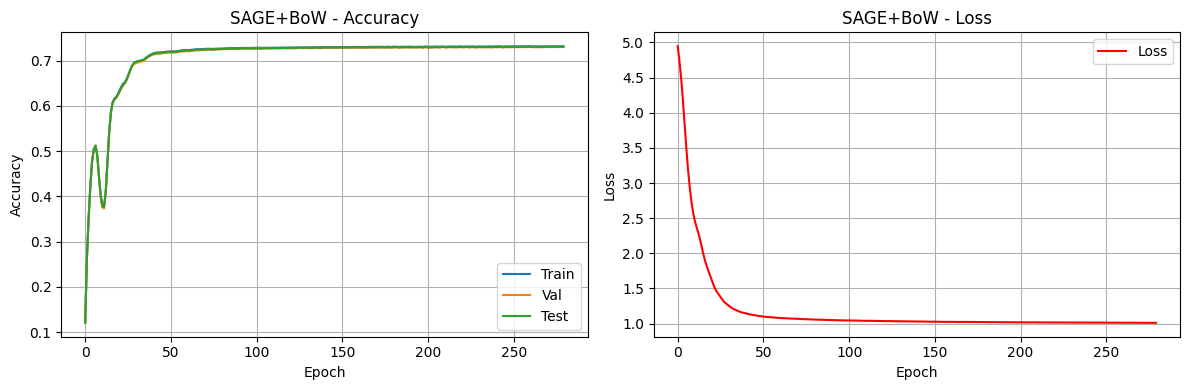

In [27]:
# BoW baseline
print(" GraphSAGE + BoW ")
val_bow, test_bow = train_sage_full(X_bow, in_channels=128, model_name="SAGE+BoW")




 GraphSAGE + BERT MiniLM 
Epoch  20 | Loss: 1.3364 | Train: 0.6642 | Val: 0.6647 | Test: 0.6631
Epoch  40 | Loss: 1.0561 | Train: 0.7251 | Val: 0.7221 | Test: 0.7249
Epoch  60 | Loss: 0.9907 | Train: 0.7432 | Val: 0.7392 | Test: 0.7410
Epoch  80 | Loss: 0.9515 | Train: 0.7513 | Val: 0.7468 | Test: 0.7492
Epoch 100 | Loss: 0.9284 | Train: 0.7561 | Val: 0.7518 | Test: 0.7522
Epoch 120 | Loss: 0.9143 | Train: 0.7590 | Val: 0.7543 | Test: 0.7555
Epoch 140 | Loss: 0.9040 | Train: 0.7602 | Val: 0.7554 | Test: 0.7563
Epoch 160 | Loss: 0.8976 | Train: 0.7618 | Val: 0.7574 | Test: 0.7574
Epoch 180 | Loss: 0.8924 | Train: 0.7621 | Val: 0.7575 | Test: 0.7580
Epoch 200 | Loss: 0.8876 | Train: 0.7633 | Val: 0.7583 | Test: 0.7586
Early stopping at epoch 219

Best Val Acc:  0.7597
Best Test Acc: 0.7586


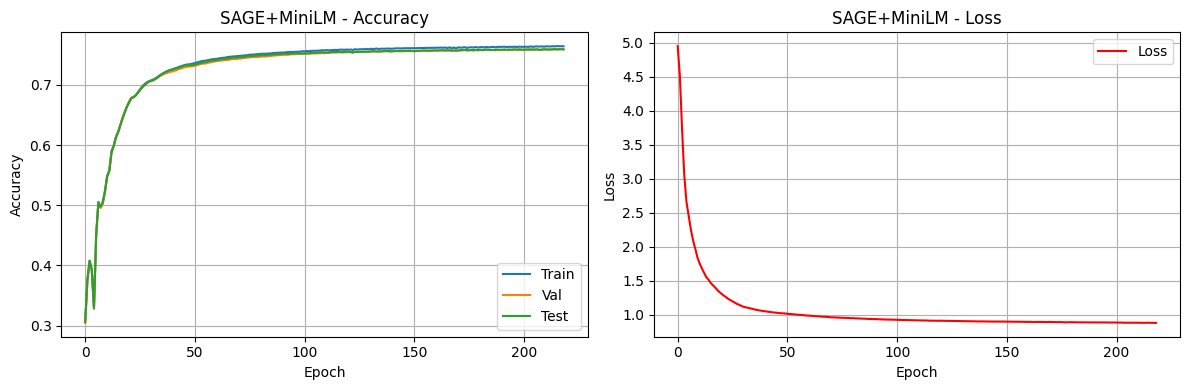

In [28]:
# BERT small
print(" GraphSAGE + BERT MiniLM ")
val_minilm, test_minilm = train_sage_full(X_bert, in_channels=384, model_name="SAGE+MiniLM")

 GraphSAGE + BERT Large 
Epoch  20 | Loss: 1.2711 | Train: 0.6801 | Val: 0.6800 | Test: 0.6806
Epoch  40 | Loss: 1.0129 | Train: 0.7370 | Val: 0.7367 | Test: 0.7370
Epoch  60 | Loss: 0.9382 | Train: 0.7548 | Val: 0.7532 | Test: 0.7540
Epoch  80 | Loss: 0.8985 | Train: 0.7625 | Val: 0.7593 | Test: 0.7610
Epoch 100 | Loss: 0.8776 | Train: 0.7664 | Val: 0.7634 | Test: 0.7657
Epoch 120 | Loss: 0.8678 | Train: 0.7665 | Val: 0.7632 | Test: 0.7641
Epoch 140 | Loss: 0.8593 | Train: 0.7695 | Val: 0.7659 | Test: 0.7676
Epoch 160 | Loss: 0.8552 | Train: 0.7710 | Val: 0.7667 | Test: 0.7689
Epoch 180 | Loss: 0.8550 | Train: 0.7679 | Val: 0.7647 | Test: 0.7657
Epoch 200 | Loss: 0.8468 | Train: 0.7712 | Val: 0.7680 | Test: 0.7695
Epoch 220 | Loss: 0.8450 | Train: 0.7708 | Val: 0.7672 | Test: 0.7691
Early stopping at epoch 239

Best Val Acc:  0.7696
Best Test Acc: 0.7711


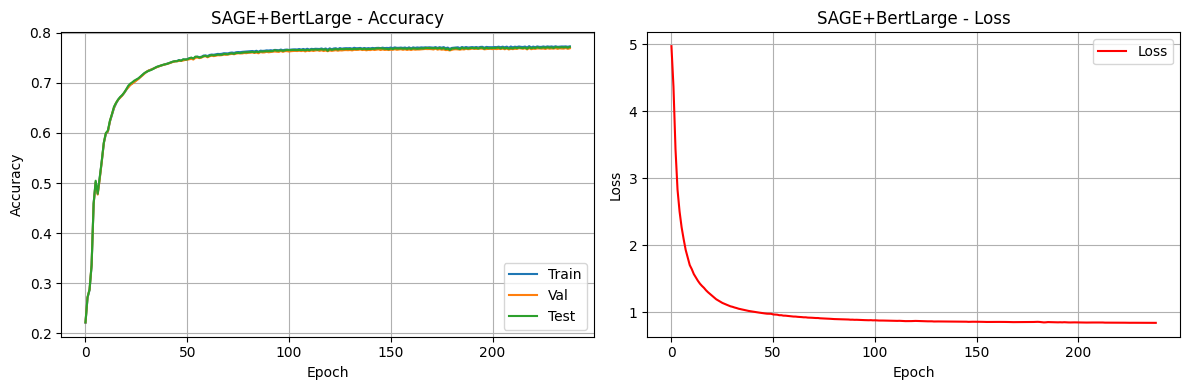

In [30]:
# BERT Large
print(" GraphSAGE + BERT Large ")
val_large, test_large = train_sage_full(X_bert_large, in_channels=768, model_name="SAGE+BertLarge")

### CLIP

In [31]:
from transformers import CLIPTokenizer, CLIPTextModel
import torch
import numpy as np


clip_text_model = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

texts = df['text'].tolist()
X_clip_text = []

clip_text_model.eval()
batch_size = 256

with torch.no_grad():
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = clip_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors="pt"
        ).to(device)
        outputs = clip_text_model(**inputs)
        # extract pooled output → the [CLS] token embedding
        embeddings = outputs.pooler_output  # ← this is the tensor
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
        X_clip_text.append(embeddings.cpu().numpy())
        if i % 10000 == 0:
            print(f"Processed {i}/{len(texts)}")

X_clip_text = np.vstack(X_clip_text)
print(f"CLIP text embeddings shape: {X_clip_text.shape}")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.l

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Processed 0/317329
Processed 160000/317329
CLIP text embeddings shape: (317329, 512)


 GraphSAGE + CLIP text 
Epoch  20 | Loss: 1.2580 | Train: 0.6931 | Val: 0.6911 | Test: 0.6963
Epoch  40 | Loss: 0.9720 | Train: 0.7490 | Val: 0.7482 | Test: 0.7516
Epoch  60 | Loss: 0.8846 | Train: 0.7732 | Val: 0.7712 | Test: 0.7750
Epoch  80 | Loss: 0.8430 | Train: 0.7829 | Val: 0.7789 | Test: 0.7827
Epoch 100 | Loss: 0.8250 | Train: 0.7864 | Val: 0.7819 | Test: 0.7867
Epoch 120 | Loss: 0.8130 | Train: 0.7886 | Val: 0.7843 | Test: 0.7887
Epoch 140 | Loss: 0.8083 | Train: 0.7873 | Val: 0.7833 | Test: 0.7877
Epoch 160 | Loss: 0.7994 | Train: 0.7907 | Val: 0.7859 | Test: 0.7902
Epoch 180 | Loss: 0.7927 | Train: 0.7908 | Val: 0.7860 | Test: 0.7908
Early stopping at epoch 195

Best Val Acc:  0.7868
Best Test Acc: 0.7906


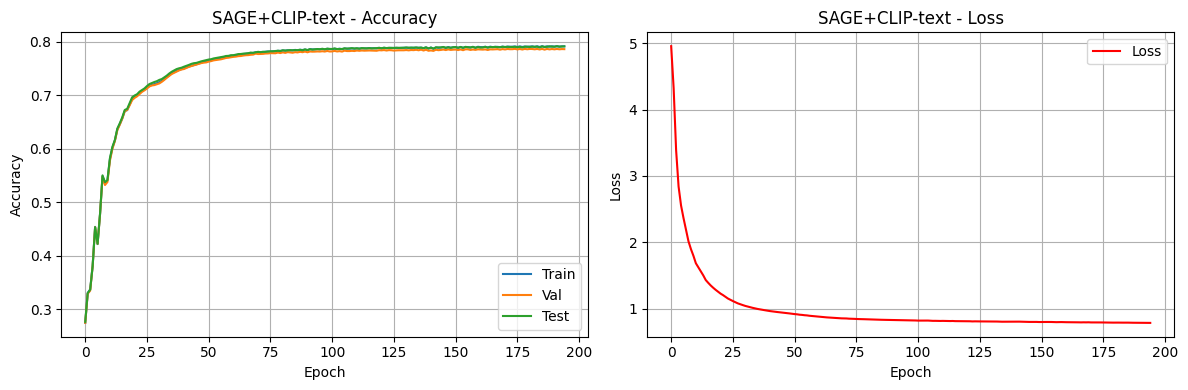

In [32]:
print(" GraphSAGE + CLIP text ")
val_clip, test_clip = train_sage_full(
    X_clip_text,
    in_channels=512,
    model_name="SAGE+CLIP-text"
)

In [33]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

def get_qwen_embeddings(model_name, texts, batch_size=64):
    print(f"Loading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, torch_dtype=torch.float16).to(device)
    model.eval()

    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt"
            ).to(device)
            outputs = model(**inputs)
            # mean pooling
            mask = inputs['attention_mask'].unsqueeze(-1).float()
            emb = (outputs.last_hidden_state * mask).sum(1) / mask.sum(1)
            emb = emb / emb.norm(dim=-1, keepdim=True)
            embeddings.append(emb.cpu().float().numpy())
            if i % 5000 == 0:
                print(f"  {i}/{len(texts)}")

    return np.vstack(embeddings)

texts = df['text'].tolist()
X_qwen_06b = get_qwen_embeddings("Qwen/Qwen3-Embedding-0.6B", texts)
print(f"Shape: {X_qwen_06b.shape}")

Loading Qwen/Qwen3-Embedding-0.6B...


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.71k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  0/317329
  40000/317329
  80000/317329
  120000/317329
  160000/317329
  200000/317329
  240000/317329
  280000/317329
Shape: (317329, 1024)


 GraphSAGE + QWEN 
Epoch  20 | Loss: 1.6421 | Train: 0.5763 | Val: 0.5767 | Test: 0.5762
Epoch  40 | Loss: 1.1926 | Train: 0.6991 | Val: 0.6999 | Test: 0.7018
Epoch  60 | Loss: 1.0620 | Train: 0.7323 | Val: 0.7316 | Test: 0.7331
Epoch  80 | Loss: 0.9933 | Train: 0.7445 | Val: 0.7433 | Test: 0.7441
Epoch 100 | Loss: 0.9663 | Train: 0.7497 | Val: 0.7478 | Test: 0.7487
Epoch 120 | Loss: 0.9447 | Train: 0.7550 | Val: 0.7535 | Test: 0.7545
Epoch 140 | Loss: 0.9318 | Train: 0.7589 | Val: 0.7574 | Test: 0.7572
Early stopping at epoch 156

Best Val Acc:  0.7584
Best Test Acc: 0.7578


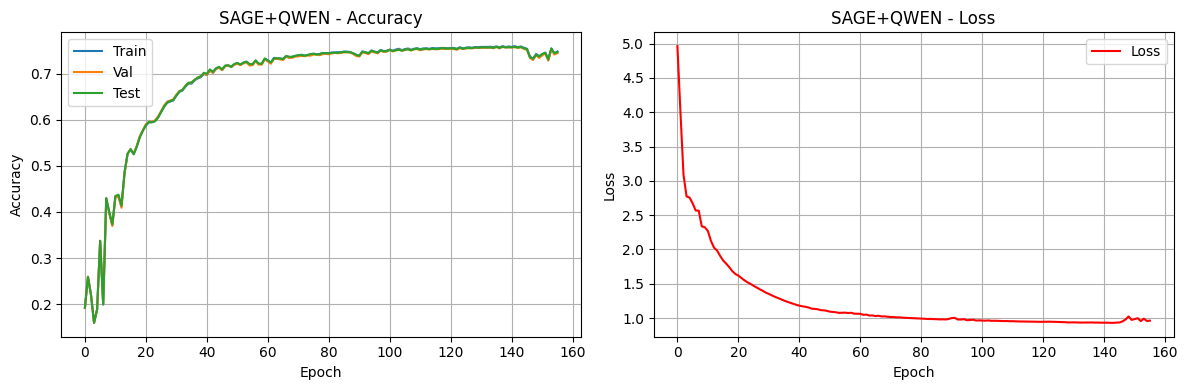

In [35]:
print(" GraphSAGE + QWEN ")
val_qwen, test_qwen = train_sage_full(
    X_qwen_06b,
    in_channels=1024,
    model_name="SAGE+QWEN"
)

In [36]:
import requests

url = "https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/image_features/image_features_Toys_and_Games.b"
r = requests.head(url)
print(f"Status: {r.status_code}")

Status: 404


In [37]:
valid_urls = df['imUrl'].notna() & df['imUrl'].str.startswith('http')
print(f"Products with image URL: {valid_urls.sum()} / {len(df)}")

# check a few URLs
print(df[valid_urls]['imUrl'].head(5).tolist())

Products with image URL: 317182 / 317329
['http://ecx.images-amazon.com/images/I/414PLROXy-L._SY300_.jpg', 'http://ecx.images-amazon.com/images/I/51ObabPu3tL._SY300_.jpg', 'http://ecx.images-amazon.com/images/I/51%2B7EjlJmDL._SL500_SY300_.jpg', 'http://ecx.images-amazon.com/images/I/51VK%2BLvWiTL._SY300_.jpg', 'http://g-ecx.images-amazon.com/images/G/01/x-site/icons/no-img-sm._CB192198896_.gif']


In [43]:

df_images = pd.read_parquet('/content/embeddings_toys_checkpoint.parquet')
print(df_images.shape)
print(df_images.columns.tolist())
print(df_images.head(2))

(14096, 4)
['asin', 'emb_resnet', 'emb_clip', 'emb_dinov2']
         asin                                         emb_resnet  \
0  0000191639  [0.042710416, 0.0, 0.19039534, 0.5604668, 0.0,...   
1  0005069491  [0.0, 0.0, 0.59008425, 0.007934907, 0.0, 0.042...   

                                            emb_clip  \
0  [1.4590938, -1.367724, 0.21205816, 0.7535517, ...   
1  [0.7827116, -0.42415294, 0.46632335, 0.5147037...   

                                          emb_dinov2  
0  [1.9937403, 0.31667408, 3.3715808, -2.8429894,...  
1  [-0.26455104, 0.3938382, 1.9390748, 0.57268244...  


In [44]:
# merge with our df on asin
df_merged = df[['asin', 'label_idx']].merge(df_images, on='asin', how='left')

print(f"Products with image embeddings: {df_merged['emb_clip'].notna().sum()}")
print(f"Products without: {df_merged['emb_clip'].isna().sum()}")

Products with image embeddings: 13248
Products without: 304081


In [45]:
def extract_embeddings(series):
    dim = len(series.dropna().iloc[0])
    result = np.zeros((len(series), dim), dtype=np.float32)
    for i, emb in enumerate(series):
        if emb is not None and not isinstance(emb, float):
            result[i] = emb
    return result

X_resnet  = extract_embeddings(df_merged['emb_resnet'])
print(f"ResNet shape:  {X_resnet.shape}")

ResNet shape:  (317329, 2048)


In [46]:
X_clip_im = extract_embeddings(df_merged['emb_clip'])
print(f"CLIP image shape: {X_clip_im.shape}")

CLIP image shape: (317329, 768)


In [47]:
X_dinov2 = extract_embeddings(df_merged['emb_dinov2'])
print(f"DINOv2 shape: {X_dinov2.shape}")

DINOv2 shape: (317329, 768)


In [48]:
# CLIP text + CLIP image
X_clip_multimodal = np.concatenate([X_clip_text, X_clip_im], axis=1)
print(f"CLIP text+image shape: {X_clip_multimodal.shape}")

# BERT large + DINOv2
X_bert_dinov2 = np.concatenate([X_bert_large, X_dinov2], axis=1)
print(f"BERT+DINOv2 shape: {X_bert_dinov2.shape}")

# BERT large + CLIP image
X_bert_clip_im = np.concatenate([X_bert_large, X_clip_im], axis=1)
print(f"BERT+CLIP image shape: {X_bert_clip_im.shape}")

CLIP text+image shape: (317329, 1280)
BERT+DINOv2 shape: (317329, 1536)
BERT+CLIP image shape: (317329, 1536)


=== GraphSAGE + CLIP text + CLIP image ===
Epoch  20 | Loss: 1.2604 | Train: 0.6809 | Val: 0.6784 | Test: 0.6827
Epoch  40 | Loss: 0.9719 | Train: 0.7527 | Val: 0.7481 | Test: 0.7519
Epoch  60 | Loss: 0.8746 | Train: 0.7771 | Val: 0.7710 | Test: 0.7731
Epoch  80 | Loss: 0.8366 | Train: 0.7858 | Val: 0.7791 | Test: 0.7812
Epoch 100 | Loss: 0.8162 | Train: 0.7874 | Val: 0.7798 | Test: 0.7817
Epoch 120 | Loss: 0.8433 | Train: 0.7771 | Val: 0.7697 | Test: 0.7735
Early stopping at epoch 131

Best Val Acc:  0.7830
Best Test Acc: 0.7857


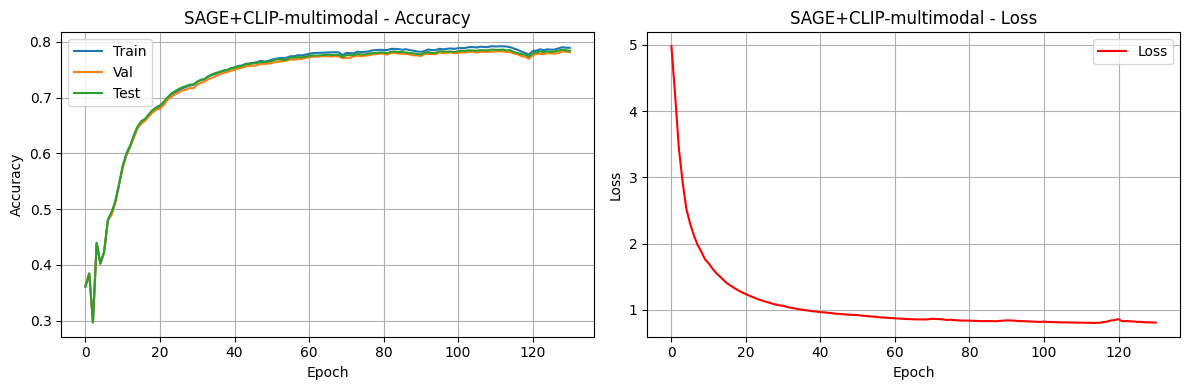


=== GraphSAGE + BERT large + DINOv2 ===
Epoch  20 | Loss: 1.2138 | Train: 0.6958 | Val: 0.6920 | Test: 0.6931
Epoch  40 | Loss: 0.9828 | Train: 0.7480 | Val: 0.7388 | Test: 0.7404
Epoch  60 | Loss: 0.9153 | Train: 0.7646 | Val: 0.7534 | Test: 0.7542
Epoch  80 | Loss: 0.8693 | Train: 0.7730 | Val: 0.7602 | Test: 0.7604
Epoch 100 | Loss: 0.8485 | Train: 0.7754 | Val: 0.7626 | Test: 0.7621
Epoch 120 | Loss: 0.8444 | Train: 0.7745 | Val: 0.7617 | Test: 0.7630
Epoch 140 | Loss: 0.8304 | Train: 0.7796 | Val: 0.7648 | Test: 0.7648
Epoch 160 | Loss: 0.8245 | Train: 0.7806 | Val: 0.7655 | Test: 0.7671
Epoch 180 | Loss: 0.8179 | Train: 0.7794 | Val: 0.7635 | Test: 0.7656
Epoch 200 | Loss: 0.8931 | Train: 0.7595 | Val: 0.7500 | Test: 0.7516
Early stopping at epoch 212

Best Val Acc:  0.7668
Best Test Acc: 0.7675


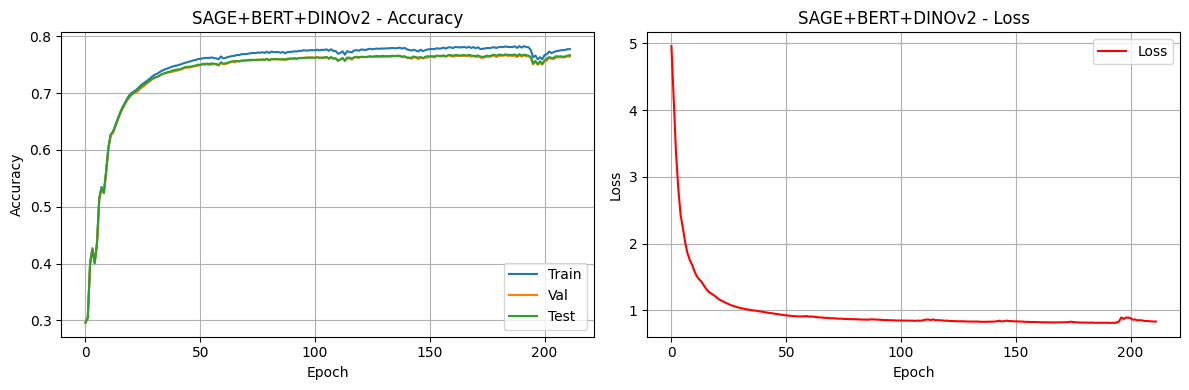

In [49]:
# CLIP text + CLIP image
print("=== GraphSAGE + CLIP text + CLIP image ===")
val_clip_mm, test_clip_mm = train_sage_full(
    X_clip_multimodal,
    in_channels=X_clip_multimodal.shape[1],
    model_name="SAGE+CLIP-multimodal"
)

# BERT + DINOv2
print("\n=== GraphSAGE + BERT large + DINOv2 ===")
val_bert_dino, test_bert_dino = train_sage_full(
    X_bert_dinov2,
    in_channels=X_bert_dinov2.shape[1],
    model_name="SAGE+BERT+DINOv2"
)

CLIP text + DINOv2 shape: (317329, 1280)
=== GraphSAGE + CLIP text + DINOv2 ===
Epoch  20 | Loss: 1.2250 | Train: 0.6897 | Val: 0.6856 | Test: 0.6896
Epoch  40 | Loss: 0.9535 | Train: 0.7587 | Val: 0.7505 | Test: 0.7540
Epoch  60 | Loss: 0.8643 | Train: 0.7789 | Val: 0.7682 | Test: 0.7709
Epoch  80 | Loss: 0.8131 | Train: 0.7919 | Val: 0.7787 | Test: 0.7814
Epoch 100 | Loss: 0.7940 | Train: 0.7954 | Val: 0.7813 | Test: 0.7842
Epoch 120 | Loss: 0.7876 | Train: 0.7955 | Val: 0.7814 | Test: 0.7852
Epoch 140 | Loss: 0.7775 | Train: 0.7961 | Val: 0.7804 | Test: 0.7844
Epoch 160 | Loss: 0.7848 | Train: 0.7935 | Val: 0.7801 | Test: 0.7840
Early stopping at epoch 161

Best Val Acc:  0.7840
Best Test Acc: 0.7878


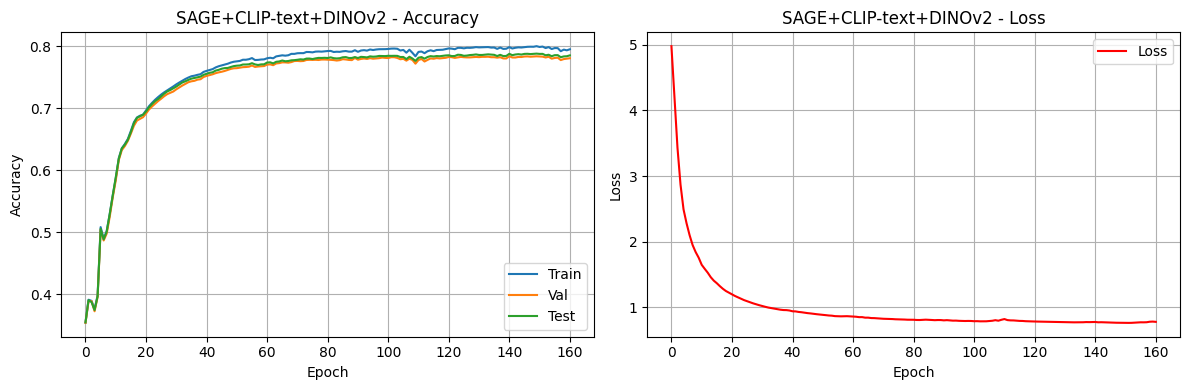

In [ ]:
    # concatenate CLIP text + DINOv2
X_clip_dinov2 = np.concatenate([X_clip_text, X_dinov2], axis=1)
print(f"CLIP text + DINOv2 shape: {X_clip_dinov2.shape}")

print("=== GraphSAGE + CLIP text + DINOv2 ===")
val_clip_dino, test_clip_dino = train_sage_full(
    X_clip_dinov2,
    in_channels=X_clip_dinov2.shape[1],
    model_name="SAGE+CLIP-text+DINOv2"
)